In [147]:
%%time
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

import pandas as pd
import wandb
import pandas as pd
from collections import defaultdict

# Table processing
def process_line(means, highlight, highlight_index, highlight_max, ignore_std):
    if highlight:
        if highlight_max:
            tops = set(means.groupby(highlight_index).idxmax())
        else:
            tops = set(means.groupby(highlight_index).idxmin())
    else:
        tops = set()

    def process_line(x):
        if ignore_std:
            if x.name in tops:
                return rf"\textbf{{{x['mean']:0.3f}}}"
            return rf"{x['mean']:0.3f}"
        if x.name in tops:
            return rf"\textbf{{{x['mean']:0.3f} $\pm$ {x['std']:0.3f}}}"
        return rf"{x['mean']:0.3f} $\pm$ {x['std']:0.3f}"

    return process_line


def mean_pm_std(
    data,
    index,
    columns,
    value,
    highlight=True,
    highlight_cols=True,
    highlight_max=True,
    ignore_std=False,
):
    assert len(data) > 0
    groupby = data.groupby([*index, *columns])
    means = groupby.mean()[value].rename("mean")
    stds = groupby.std()[value].rename("std")
    ddf = pd.concat([means, stds], axis=1).T
    highlight_index = columns if highlight_cols else index
    ddf = ddf.apply(
        process_line(means, highlight, highlight_index, highlight_max, ignore_std)
    )
    ddf = ddf.reset_index().pivot(index=index, columns=columns)
    ddf.columns = ddf.columns.droplevel(level=0)
    
    return ddf

    
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def prepare_data(data):
    flattened_data = [flatten_dict(item) for item in data]
    return pd.DataFrame(flattened_data)



The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPU times: user 889 μs, sys: 792 μs, total: 1.68 ms
Wall time: 1.93 ms


In [148]:
api = wandb.Api(timeout=30)

# Project is specified by <entity/project-name>
runs = api.runs(
    "openproblems-comp/fast-tbg",
    filters={
        "$and": [
            {
                # "created_at": {"$gt": "2025-01-26T00:00:00"},
                "tags": {"$in": ["jarz_rs"]},
                #'group': {'$in': ['5_vars']},
                # "config.data.n_particles": {"$eq": 22},
                #'config.model': {'$eq': model},
                #'config.lr': {'$lt': 1.01 * lr, '$gt': 0.99 * lr},
            }
        ]
    },
)

summary_list, config_list, name_list, tag_list = [], [], [], []
for run in runs:
    tag_list.append(run.tags)
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)
    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
    # .name is the human-readable name of the run.
    name_list.append(run.name)
df_summary = prepare_data(summary_list)
df_config = prepare_data(config_list)
tag_list = [str(t) for t in tag_list]
df = pd.concat(
    [
        pd.DataFrame(name_list, columns=["name"]),
        pd.DataFrame(tag_list, columns=["Tags"]),
        df_summary,
        df_config,
    ],
    axis=1,
)

In [149]:
metrics = [
    "test/cropped_energy_w1",
    "test/rama/torus_wasserstein",
    "test/resampled/energy_w1",
    "test/resampled/rama/torus_wasserstein",
    "test/jarzynski/energy_w1",
    "test/jarzynski/rama/torus_wasserstein",
    "test/jarzynski/effective_sample_size",
    "test/jarzynski/rama/torus_wasserstein",
]

In [150]:
import math


def filterer(x):
    if isinstance(x, float) and not math.isfinite(x):
        return False
    return "table" in list(x)


filtered_df = df[
    # df["model/_target_"].isin(["src.models.flow_matching_module.FlowMatchLitModule"])
    # & df["Tags"].apply(lambda x: "eval" in x)
    df["Tags"].apply(lambda x: True)
    # & ~df["val/cropped_energy_w1"].isna()
    # & df["tags"].apply(filterer)
][
    [
        # "tags",
        "model/_target_",
        "model/net/_target_",
        "data/n_particles",
        "model/jarzynski_sampler/ess_threshold",
        "model/use_com_energy",
        *metrics,
    ]
].drop(
    columns=["model/_target_"]
)

# filtered_df.sort_values("data/n_particles")

In [151]:
renamed_df = filtered_df.replace(
    {
        "src.models.components.tbg.egnn_dynamics_ad2_cat.EGNN_dynamics_AD2_cat": "EQ-CFM",
        "src.models.components.dit.DIT3D": "DiT-CFM",
        "src.models.components.tarflow.TarFlow": "TarFlow",
    }
).rename(
    columns={
        "model/net/_target_": "Model",
        "data/n_particles": "n_particles",
        "model/jarzynski_sampler/ess_threshold": "ess_threshold",
    }
)

In [152]:
renamed_df.groupby(["Model", "n_particles"]).count()

ess_threshold  model/use_com_energy  \
Model   n_particles                                        
TarFlow 22                     107                   107   
        33                     108                   108   
        42                     108                   108   

                     test/cropped_energy_w1  test/rama/torus_wasserstein  \
Model   n_particles                                                        
TarFlow 22                              107                          107   
        33                              108                          108   
        42                              106                          106   

                     test/resampled/energy_w1  \
Model   n_particles                             
TarFlow 22                                107   
        33                                108   
        42                                106   

                     test/resampled/rama/torus_wasserstein  \
Model   n_particles                                          
TarFlow 22                                             107   
        33                                             108   
        42                                             106   

                     test/jarzynski/energy_w1  \
Model   n_particles                             
TarFlow 22                                107   
        33                                108   
        42                                106   

                     test/jarzynski/rama/torus_wasserstein  \
Model   n_particles                                          
TarFlow 22                                             107   
        33                                             108   
        42                                             106   

                     test/jarzynski/effective_sample_size  \
Model   n_particles                                         
TarFlow 22                                            107   
        33                                            108   
        42                                            106   

                     test/jarzynski/rama/torus_wasserstein  
Model   n_particles                                         
TarFlow 22                                             107  
        33                                             108  
        42                                             106

In [155]:
renamed_df = renamed_df.drop(columns=["Model"])

renamed_df["test/jarzynski/energy_w1"].dtype

KeyError: "['Model'] not found in axis"

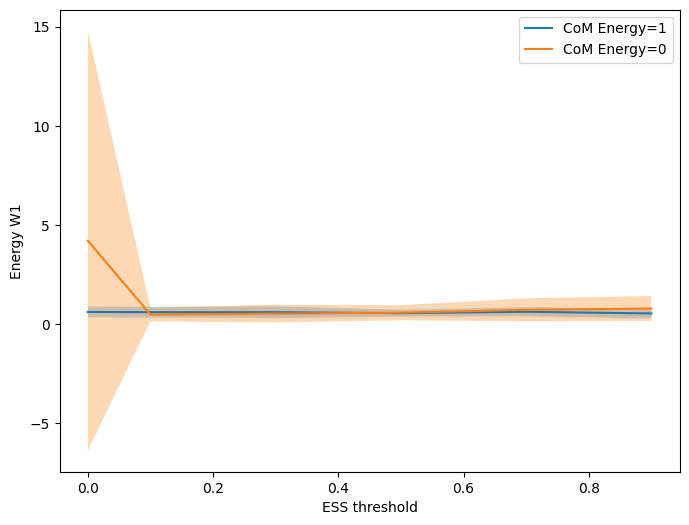

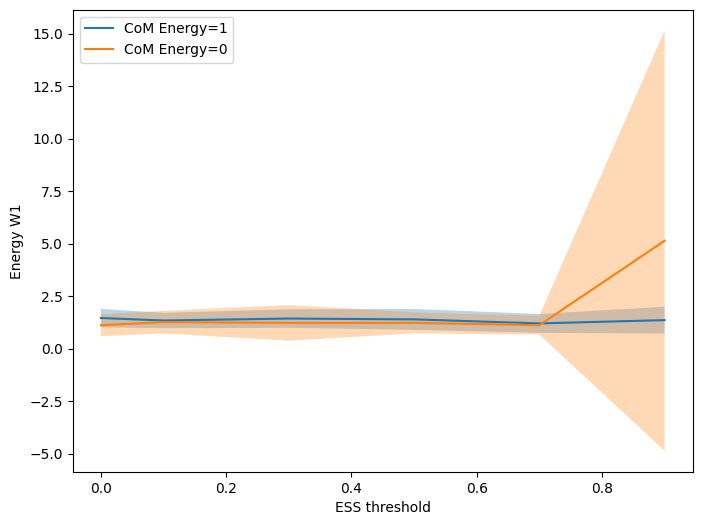

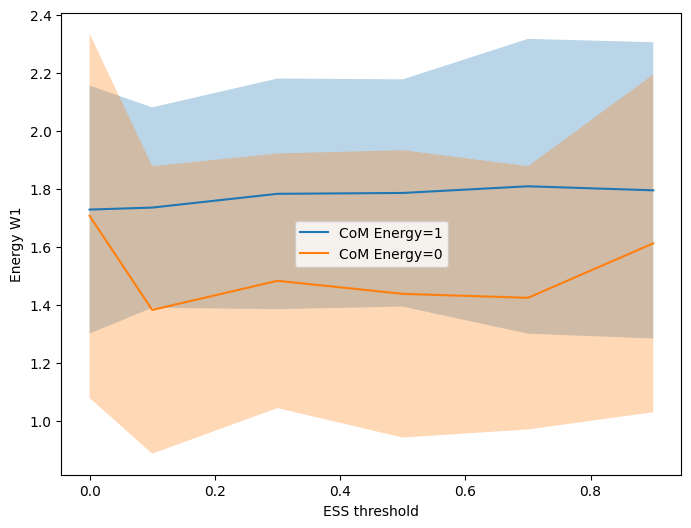

In [156]:
import matplotlib.pyplot as plt

for n_particles in [22, 33, 42]:

    plt.figure(figsize=(8, 6))
    for use_com_energy in renamed_df["model/use_com_energy"].unique():
        particles_df = renamed_df[
            (renamed_df["n_particles"] == n_particles)
            & (renamed_df["model/use_com_energy"] == use_com_energy)
        ]

        particles_df = particles_df.groupby(["ess_threshold"])

        means = particles_df.mean()["test/jarzynski/energy_w1"]

        stds = particles_df.std()["test/jarzynski/energy_w1"]

        plt.plot(
            means.index,
            means,
            label=f"CoM Energy={use_com_energy}",
        )
        plt.fill_between(
            means.index,
            means - stds,
            means + stds,
            alpha=0.3,
        )
    plt.xlabel("ESS threshold")
    plt.ylabel("Energy W1")

    plt.legend()
    plt.show()

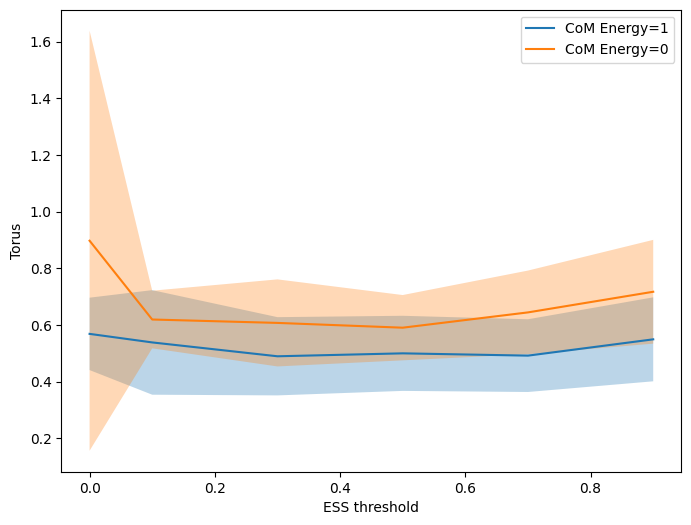

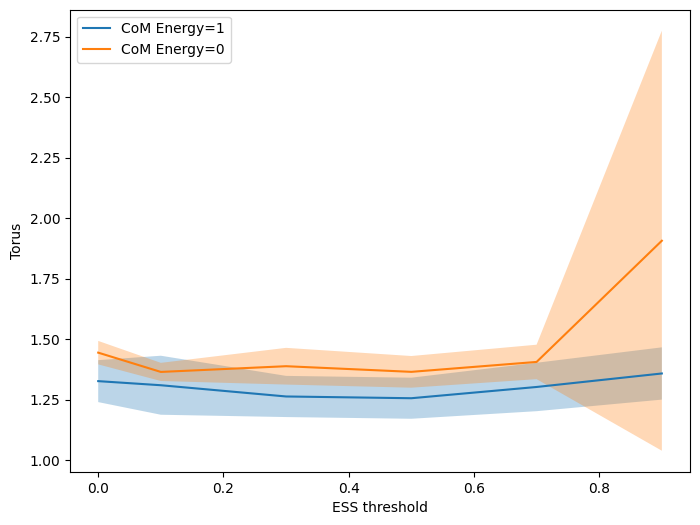

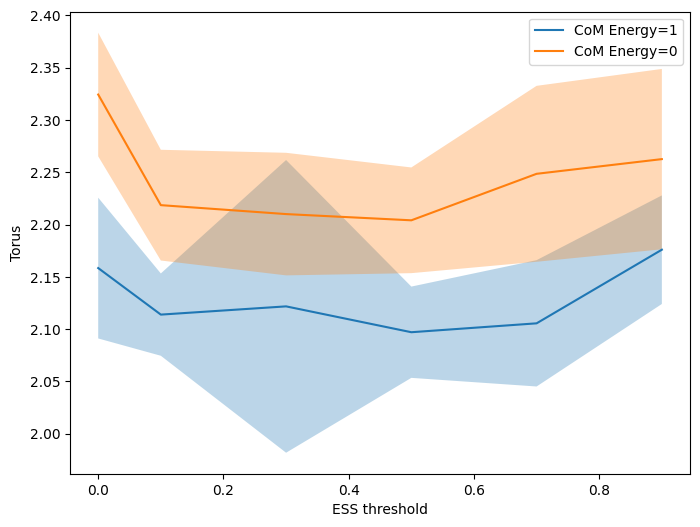

In [163]:
import matplotlib.pyplot as plt

for n_particles in [22, 33, 42]:

    plt.figure(figsize=(8, 6))
    for use_com_energy in renamed_df["model/use_com_energy"].unique():
        particles_df = renamed_df[
            (renamed_df["n_particles"] == n_particles)
            & (renamed_df["model/use_com_energy"] == use_com_energy)
        ]

        particles_df = particles_df.groupby(["ess_threshold"])

        means = particles_df.mean()["test/jarzynski/rama/torus_wasserstein"]
        stds = particles_df.std()["test/jarzynski/rama/torus_wasserstein"]

        if means.shape == (6, 2):
            means = means.iloc[:, 0]
        if stds.shape == (6, 2):
            stds = stds.iloc[:, 0]

        plt.plot(
            means.index,
            means,
            label=f"CoM Energy={use_com_energy}",
        )
        plt.fill_between(
            means.index,
            means - stds,
            means + stds,
            alpha=0.3,
        )
    plt.xlabel("ESS threshold")
    plt.ylabel("Torus")

    plt.legend()
    plt.show()

In [ ]:
df_melt = renamed_df.dropna().melt(
    value_vars=metrics, id_vars=["Model", "n_particles", "ess_threshold"], var_name="Metric"
)

In [ ]:
results = mean_pm_std(
    df_melt,
    index=["Model"],
    columns=["n_particles", "ess_threshold", "Metric"],
    value="value",
    highlight=False,
)
results

n_particles                       22                                       \
ess_threshold                    0.5                                        
Metric        test/cropped_energy_w1 test/jarzynski/effective_sample_size   
Model                                                                       
TarFlow            9.229 $\pm$ 0.508                    0.772 $\pm$ 0.187   

n_particles                                                                   \
ess_threshold                                                                  
Metric        test/jarzynski/energy_w1 test/jarzynski/rama/torus_wasserstein   
Model                                                                          
TarFlow              0.537 $\pm$ 0.280                     0.655 $\pm$ 0.125   

n_particles                                                         \
ess_threshold                                                        
Metric        test/rama/torus_wasserstein test/resampled/energy_w1   
Model                                                                
TarFlow                 1.134 $\pm$ 0.019        0.600 $\pm$ 0.360   

n_particles                                                             33  \
ess_threshold                                                          0.5   
Metric        test/resampled/rama/torus_wasserstein test/cropped_energy_w1   
Model                                                                        
TarFlow                           0.656 $\pm$ 0.134      6.168 $\pm$ 0.709   

n_particles                                                                  \
ess_threshold                                                                 
Metric        test/jarzynski/effective_sample_size test/jarzynski/energy_w1   
Model                                                                         
TarFlow                          0.839 $\pm$ 0.224        1.251 $\pm$ 0.540   

n_particles    ...                                                       \
ess_threshold  ...                                                        
Metric         ... test/rama/torus_wasserstein test/resampled/energy_w1   
Model          ...                                                        
TarFlow        ...           0.755 $\pm$ 0.008        1.808 $\pm$ 0.517   

n_particles                                                             42  \
ess_threshold                                                          0.5   
Metric        test/resampled/rama/torus_wasserstein test/cropped_energy_w1   
Model                                                                        
TarFlow                           1.388 $\pm$ 0.054      5.673 $\pm$ 0.303   

n_particles                                                                  \
ess_threshold                                                                 
Metric        test/jarzynski/effective_sample_size test/jarzynski/energy_w1   
Model                                                                         
TarFlow                          0.697 $\pm$ 0.101        1.407 $\pm$ 0.454   

n_particles                                          \
ess_threshold                                         
Metric        test/jarzynski/rama/torus_wasserstein   
Model                                                 
TarFlow                           2.205 $\pm$ 0.085   

n_particles                                                         \
ess_threshold                                                        
Metric        test/rama/torus_wasserstein test/resampled/energy_w1   
Model                                                                
TarFlow                 1.709 $\pm$ 0.013        1.669 $\pm$ 0.443   

n_particles                                          
ess_threshold                                        
Metric        test/resampled/rama/torus_wasserstein  
Model                                                
TarFlow                           2.296 $\pm$ 0.045  

[1 rows x 21 c

In [ ]:
print(
    results.to_latex(
        float_format="{:.3f}".format,
    )
)

\begin{tabular}{llllllllllllllllllllll}
\toprule
n_particles & \multicolumn{7}{r}{22} & \multicolumn{7}{r}{33} & \multicolumn{7}{r}{42} \\
ess_threshold & \multicolumn{7}{r}{0.500000} & \multicolumn{7}{r}{0.500000} & \multicolumn{7}{r}{0.500000} \\
Metric & test/cropped_energy_w1 & test/jarzynski/effective_sample_size & test/jarzynski/energy_w1 & test/jarzynski/rama/torus_wasserstein & test/rama/torus_wasserstein & test/resampled/energy_w1 & test/resampled/rama/torus_wasserstein & test/cropped_energy_w1 & test/jarzynski/effective_sample_size & test/jarzynski/energy_w1 & test/jarzynski/rama/torus_wasserstein & test/rama/torus_wasserstein & test/resampled/energy_w1 & test/resampled/rama/torus_wasserstein & test/cropped_energy_w1 & test/jarzynski/effective_sample_size & test/jarzynski/energy_w1 & test/jarzynski/rama/torus_wasserstein & test/rama/torus_wasserstein & test/resampled/energy_w1 & test/resampled/rama/torus_wasserstein \\
Model &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  

In [36]:
df_melt["ess_threshold"].unique()

array([0.5])

In [37]:
df_melt.mean()

TypeError: Could not convert ['TarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTarFlowTar

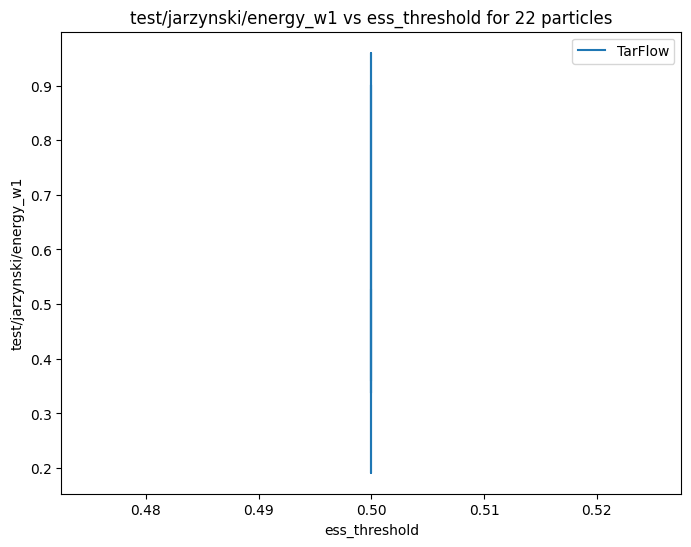

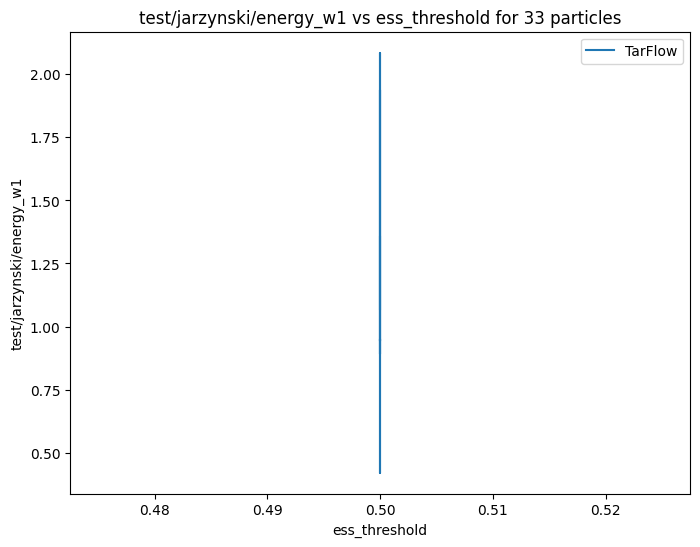

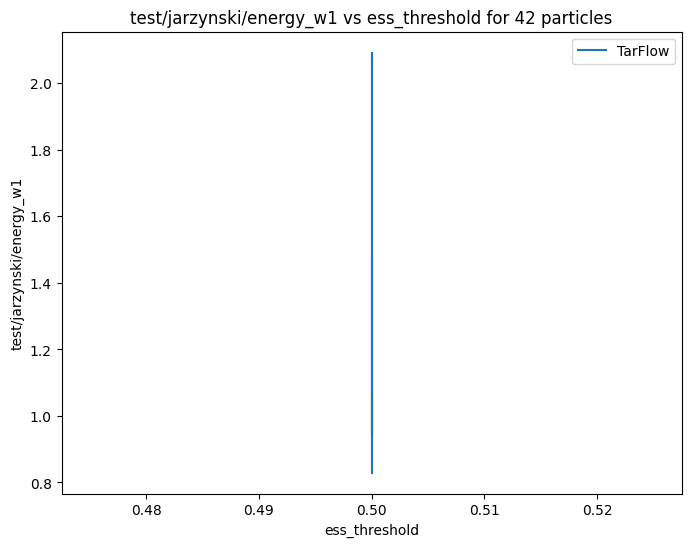

In [35]:
import matplotlib.pyplot as plt

for n_particles in df_melt["n_particles"].unique():
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    for model in df_melt["Model"].unique():
        subset = df_melt[
            (df_melt["n_particles"] == n_particles)
            & (df_melt["Model"] == model)
            & (df_melt["Metric"] == "test/jarzynski/energy_w1")
        ]
        ax.plot(subset["ess_threshold"], subset["value"], label=model)
        ax.set_title(f"test/jarzynski/energy_w1 vs ess_threshold for {n_particles} particles")
        ax.set_xlabel("ess_threshold")
        ax.set_ylabel("test/jarzynski/energy_w1")
        ax.legend()
        plt.show()